## 2D Forming Connections 

Contains code of plots like probability distributions or desired kernels. 

import utils

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
from lib.utils import *

1. Plot Von-Mises Probability Scaling

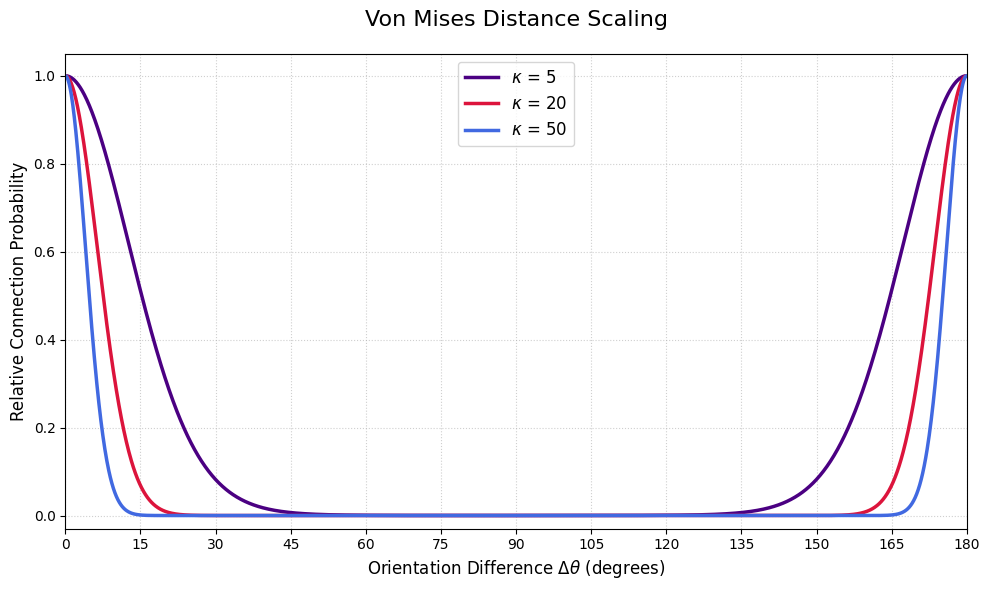

In [56]:
#############################
#   von Mises Orientation   #
#############################

kappas = [5, 20, 50]
colors = ['indigo', 'crimson', 'royalblue']

dtheta_deg = np.linspace(0, 180, 1801)

plt.figure(figsize=(10, 6))
for kappa, color in zip(kappas, colors):
    vm = np.exp(kappa * (np.cos(2 * np.radians(dtheta_deg)) - 1.0))
    plt.plot(dtheta_deg, vm, linestyle='-', color=color, linewidth=2.5,
             label=rf'$\kappa$ = {kappa}')

plt.title('Von Mises Distance Scaling', fontsize=16, pad=20)
plt.xlabel(r'Orientation Difference $\Delta\theta$ (degrees)', fontsize=12)
plt.ylabel('Relative Connection Probability', fontsize=12)
plt.xticks(np.arange(0, 181, 15))
plt.xlim(0, 180)
plt.ylim(-0.03, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

2. 2D Gaussian Filter

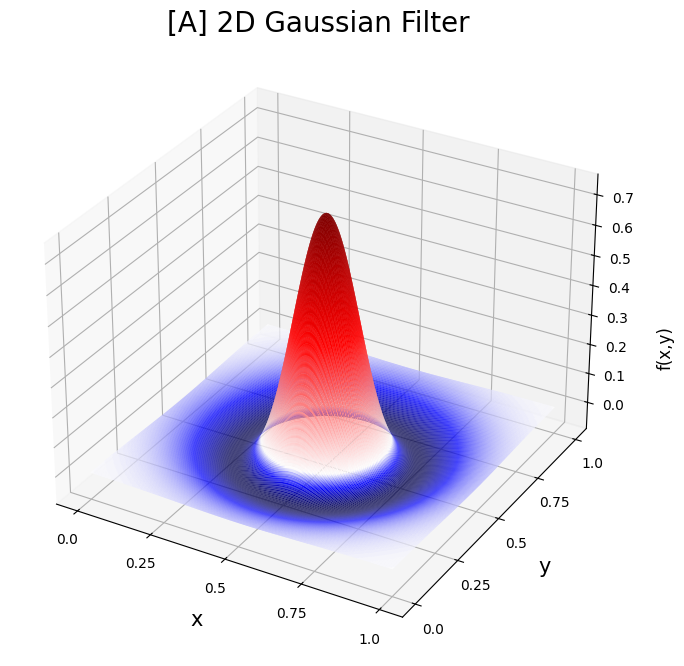

In [3]:
sigma_e = 1.0   
sigma_i = 2.0   

x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)
X, Y = np.meshgrid(x, y)

R2 = X**2 + Y**2
Z = (1/sigma_e**2) * np.exp(-R2 / (2*sigma_e**2)) \
  - (1/sigma_i**2) * np.exp(-R2 / (2*sigma_i**2))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0, vmax=Z.max())
surf = ax.plot_surface(
    X, Y, Z,
    cmap='seismic', norm=norm,
    edgecolor='none',
    rcount=300, ccount=300,
    antialiased=True,
)

ticks = np.linspace(-5, 5, 5)
tick_labels = ['0.0', '0.25', '0.5', '0.75', '1.0']
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_yticks(ticks)
ax.set_yticklabels(tick_labels)

ax.set_title('[A] 2D Gaussian Filter', fontsize=20)
ax.set_xlabel('x', labelpad=10, fontsize=15)
ax.set_ylabel('y', labelpad=10, fontsize=15)

ax.text2D(1.05, 0.5, 'f(x,y)', transform=ax.transAxes, rotation=90, 
          verticalalignment='center', horizontalalignment='left', fontsize=12)

fig.subplots_adjust(left=0.05, right=0.85)

plt.show()

3. 2D Gabor Filter

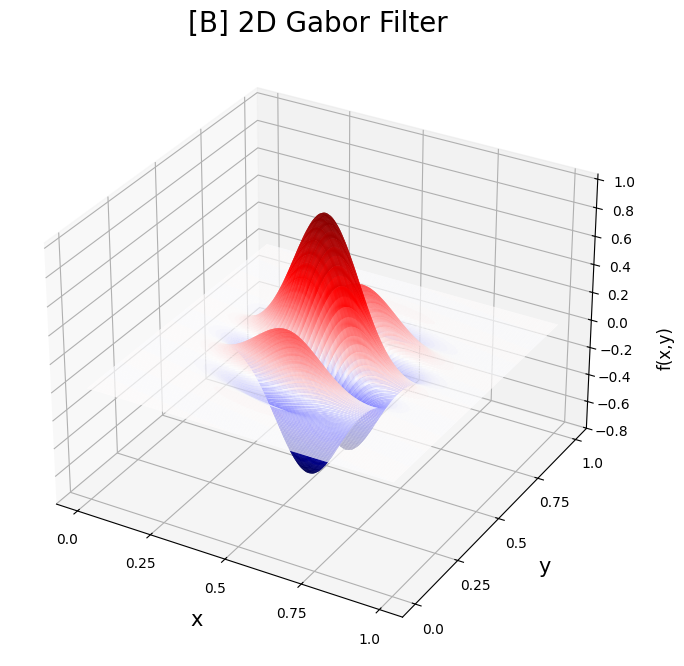

In [4]:
sigma = 1.2        
theta = np.pi/2.25       
lam = 1.8          
gamma = 1.0        
psi = 0.0          

x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)
X, Y = np.meshgrid(x, y)

X_prime = X * np.cos(theta) + Y * np.sin(theta)
Y_prime = -X * np.sin(theta) + Y * np.cos(theta)

envelope = np.exp(-(X_prime**2 + (gamma**2 * Y_prime**2)) / (2 * sigma**2))
carrier = np.cos(2 * np.pi * (X_prime / lam) + psi)

Z = envelope * carrier

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0, vmax=Z.max())
surf = ax.plot_surface(
    X, Y, Z,
    cmap='seismic', norm=norm, 
    edgecolor='none',
    rcount=300, ccount=300,
    antialiased=True,
)

ticks = np.linspace(-5, 5, 5)
tick_labels = ['0.0', '0.25', '0.5', '0.75', '1.0']
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_yticks(ticks)
ax.set_yticklabels(tick_labels)

ax.set_title('[B] 2D Gabor Filter', fontsize=20)
ax.set_xlabel('x', labelpad=10, fontsize=15)
ax.set_ylabel('y', labelpad=10, fontsize=15)

ax.text2D(1.05, 0.5, 'f(x,y)', transform=ax.transAxes, rotation=90, 
          verticalalignment='center', horizontalalignment='left', fontsize=12)

fig.subplots_adjust(left=0.05, right=0.85)

plt.show()

4. Plot Gratings

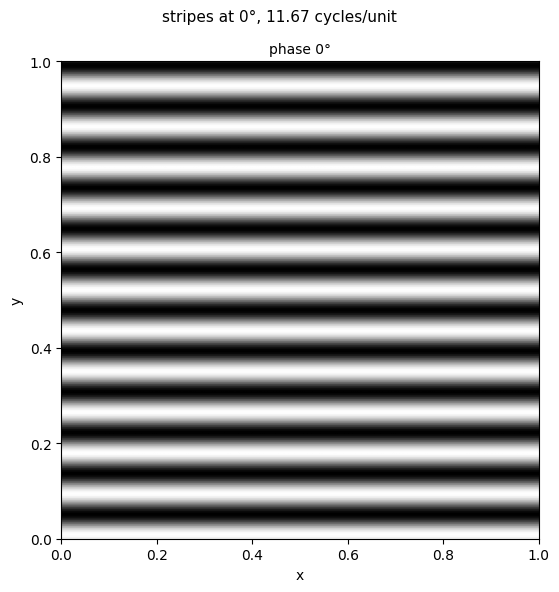

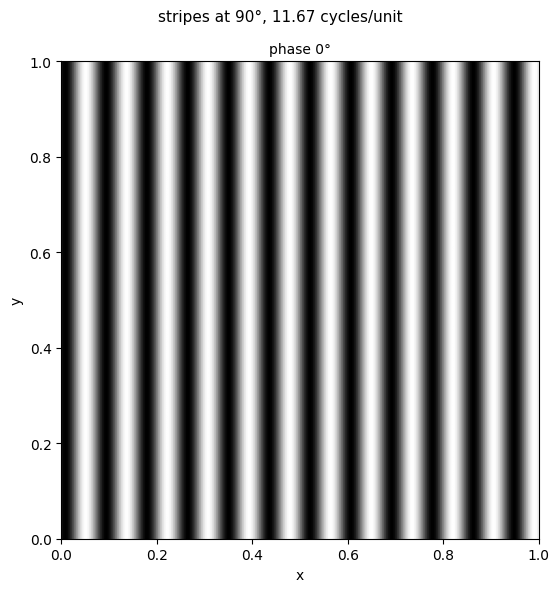

In [16]:
n = 256  
contrast = 1.0  
best_sf = 11.67   

x_coords = np.linspace(0, 1, n)
y_coords = np.linspace(0, 1, n)
xv, yv = np.meshgrid(x_coords, y_coords)
xy_L0_E = np.column_stack([xv.ravel(), yv.ravel()])

thetas = [0, np.pi / 2]

for target_theta in thetas:
    fig = plot_single_grating(xy_L0_E, n, target_theta, best_sf, zoom=1, contrast=contrast)
    plt.show()

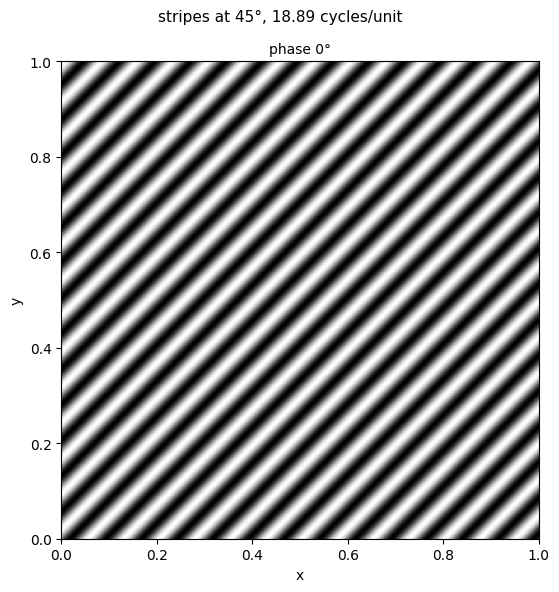

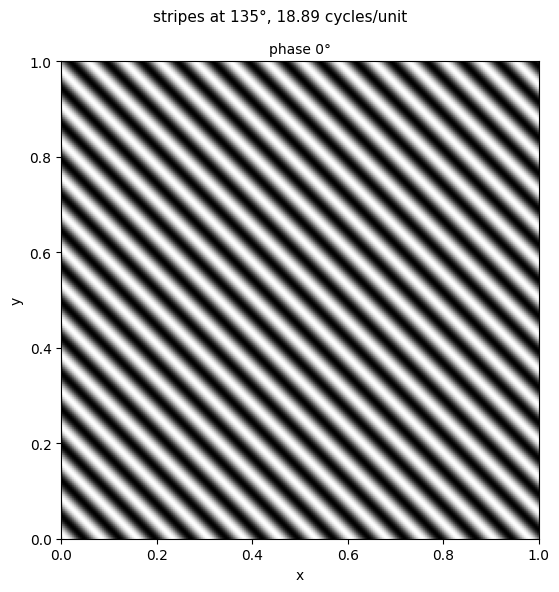

In [12]:
best_sf = 18.89   

x_coords = np.linspace(0, 1, n)
y_coords = np.linspace(0, 1, n)
xv, yv = np.meshgrid(x_coords, y_coords)
xy_L0_E = np.column_stack([xv.ravel(), yv.ravel()])

thetas = [np.pi / 4, 3*np.pi/4 ]

for target_theta in thetas:
    fig = plot_single_grating(xy_L0_E, n, target_theta, best_sf, zoom=1, contrast=contrast)
    plt.show()

5. Plot Simple Cell Receptive Field Kernel

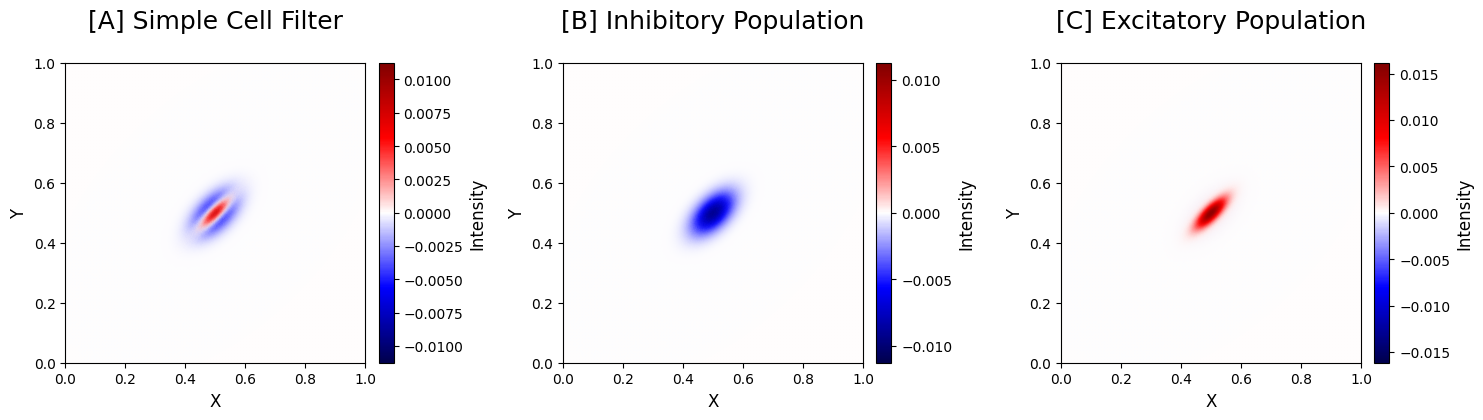

In [53]:
rng = np.random.default_rng(187)

n_grid = 5000
x0, y0 = 0.5, 0.5
theta = 0.25 * np.pi

sig_x_E, sig_y_E = 0.045, 0.016
sig_x_I, sig_y_I = 0.058, 0.032

a_E, a_I = 1.0, 0.58
peak = 0.015
noise = 0.06

g = np.linspace(0, 1, n_grid)
X, Y = np.meshgrid(g, g, indexing='xy')

dx, dy = X - x0, Y - y0
u = dx * np.cos(theta) + dy * np.sin(theta)
v = -dx * np.sin(theta) + dy * np.cos(theta)

K_E = a_E * np.exp(-0.5 * (u**2 / sig_x_E**2 + v**2 / sig_y_E**2))
K_I = a_I * np.exp(-0.5 * (u**2 / sig_x_I**2 + v**2 / sig_y_I**2))

env = np.sqrt(np.maximum(K_E, 0)) + np.sqrt(np.maximum(K_I, 0))
K_E += noise * env * rng.standard_normal(K_E.shape)
K_I += noise * env * rng.standard_normal(K_I.shape)

K = K_E - K_I
s = peak / np.abs(K).max()
K, K_E, K_I = K * s, K_E * s, K_I * s

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

panels = [(K, '[A] Simple Cell Filter'),
          (-K_I, '[B] Inhibitory Population'),
          (K_E, '[C] Excitatory Population')]

for ax, (img, title) in zip(axes, panels):
    lim = np.abs(img*0.75).max()
    im = ax.imshow(img, origin='lower', extent=[0, 1, 0, 1],
                   cmap='seismic', vmin=-lim, vmax=lim)
    ax.set_title(title, fontsize=18, pad=25)
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_xticks(np.arange(0, 1.01, 0.2))
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('Intensity', fontsize=12)

fig.tight_layout()
plt.show()

6. Plot Gabor Filter GMM

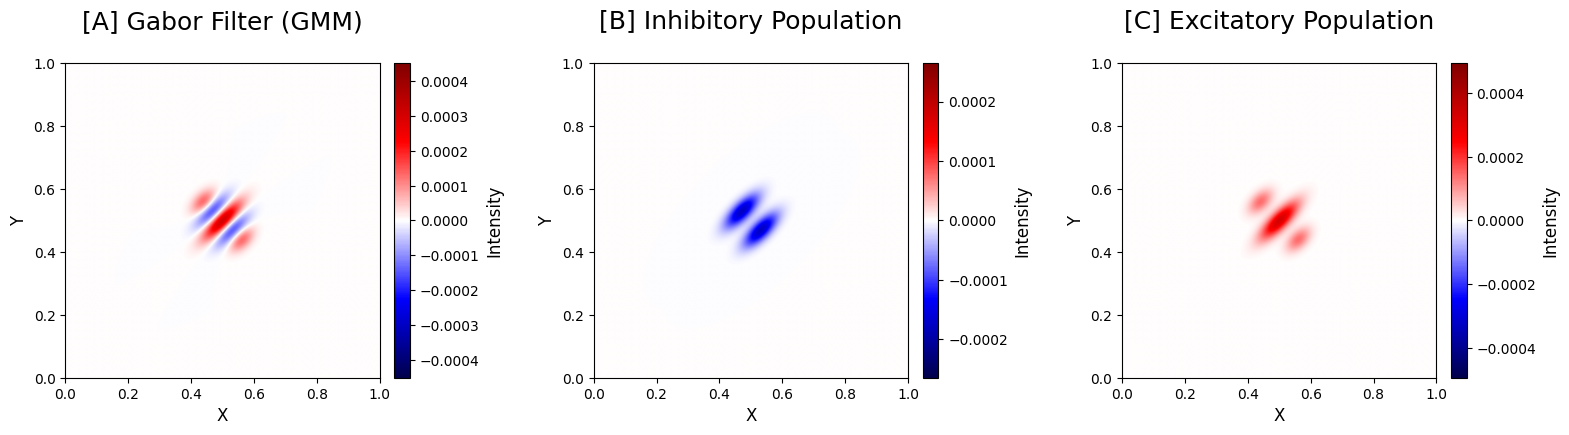

In [54]:
n_grid = 5000
x0, y0 = 0.5, 0.5
theta = 0.25 * np.pi

spacing = 0.085
sig_v = 0.019

k_E = np.array([-1.0, 0.0, 1.0])
w_E = np.array([0.30, 0.70, 0.30])
sig_u_E = np.array([0.032, 0.055, 0.032])

k_I = np.array([-0.5, 0.5])
w_I = np.array([0.5, 0.5])
sig_u_I = np.array([0.048, 0.048])

a_E, a_I = 1.0, 0.75
peak = 3e-4

g = np.linspace(0, 1, n_grid)
X, Y = np.meshgrid(g, g, indexing='xy')

dx, dy = X - x0, Y - y0
u = dx * np.cos(theta) + dy * np.sin(theta)
v = -dx * np.sin(theta) + dy * np.cos(theta)


def mixture(k, w, sig_u):
    out = np.zeros_like(u)
    for ki, wi, su in zip(k, w, sig_u):
        out += wi * np.exp(-0.5 * (u**2 / su**2 + (v - ki * spacing)**2 / sig_v**2))
    return out


K_E = a_E * mixture(k_E, w_E, sig_u_E)
K_I = a_I * mixture(k_I, w_I, sig_u_I)

K = K_E - K_I
s = peak / np.abs(K).max()
K, K_E, K_I = K * s, K_E * s, K_I * s

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

panels = [(K, '[A] Gabor Filter (GMM)'),
          (-K_I, '[B] Inhibitory Population'),
          (K_E, '[C] Excitatory Population')]
for ax, (img, title) in zip(axes, panels):
    lim = np.abs(img*1.5).max()
    im = ax.imshow(img, origin='lower', extent=[0, 1, 0, 1],
                   cmap='seismic', vmin=-lim, vmax=lim,
                   interpolation='bilinear')
    ax.set_title(title, fontsize=18, pad=25)
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_xticks(np.arange(0, 1.01, 0.2))
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('Intensity', fontsize=12)

fig.tight_layout()
plt.show()

7. Plot Gabor Filter Kernel

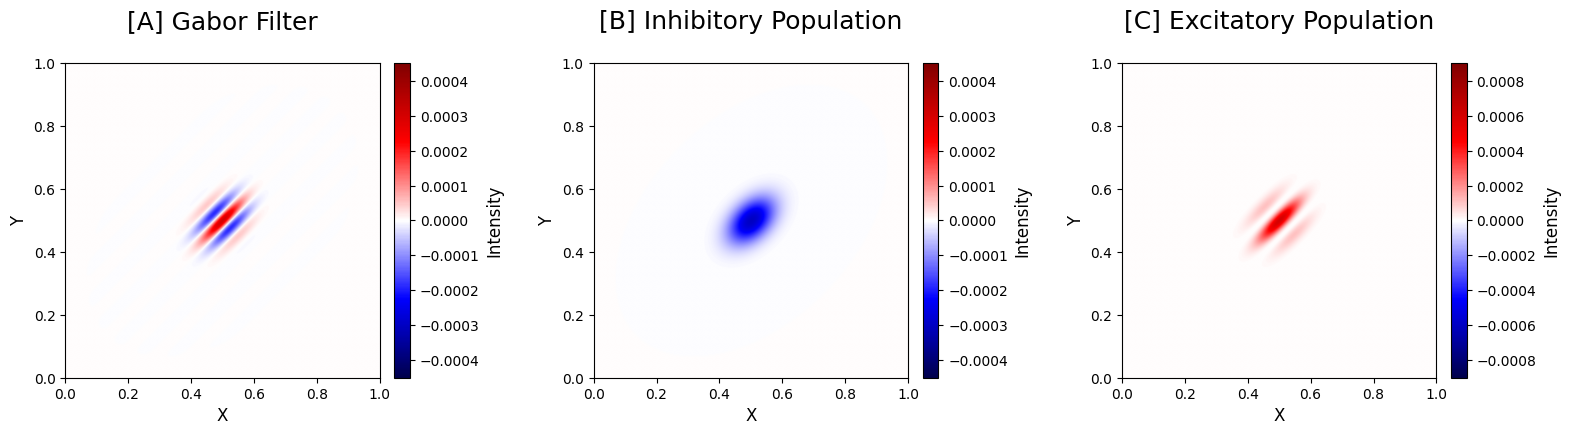

In [55]:
n_grid = 5000
x0, y0 = 0.5, 0.5
theta = 0.25 * np.pi

sig_x_E, sig_y_E = 0.060, 0.038
sig_x_I, sig_y_I = 0.060, 0.038
freq = 13.0
phase = 0.0

a_E, a_I = 1.0, 0.5
peak = 3e-4

g = np.linspace(0, 1, n_grid)
X, Y = np.meshgrid(g, g, indexing='xy')

dx, dy = X - x0, Y - y0
u = dx * np.cos(theta) + dy * np.sin(theta)
v = -dx * np.sin(theta) + dy * np.cos(theta)

env_E = np.exp(-0.5 * (u**2 / sig_x_E**2 + v**2 / sig_y_E**2))
env_I = np.exp(-0.5 * (u**2 / sig_x_I**2 + v**2 / sig_y_I**2))

K_E = a_E * env_E * (np.cos(2 * np.pi * freq * v + phase) + 1) / 2
K_I = a_I * env_I

K = K_E - K_I
s = peak / np.abs(K).max()
K, K_E, K_I = K * s, K_E * s, K_I * s

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

panels = [(K, '[A] Gabor Filter'),
          (-K_I, '[B] Inhibitory Population'),
          (K_E, '[C] Excitatory Population')]

for ax, (img, title) in zip(axes, panels):
    lim = np.abs(img*1.5).max()
    im = ax.imshow(img, origin='lower', extent=[0, 1, 0, 1],
                   cmap='seismic', vmin=-lim, vmax=lim,
                   interpolation='bilinear')
    ax.set_title(title, fontsize=18, pad=25)
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_xticks(np.arange(0, 1.01, 0.2))
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('Intensity', fontsize=12)

fig.tight_layout()
plt.show()

8. Plot Mexican hat 1D

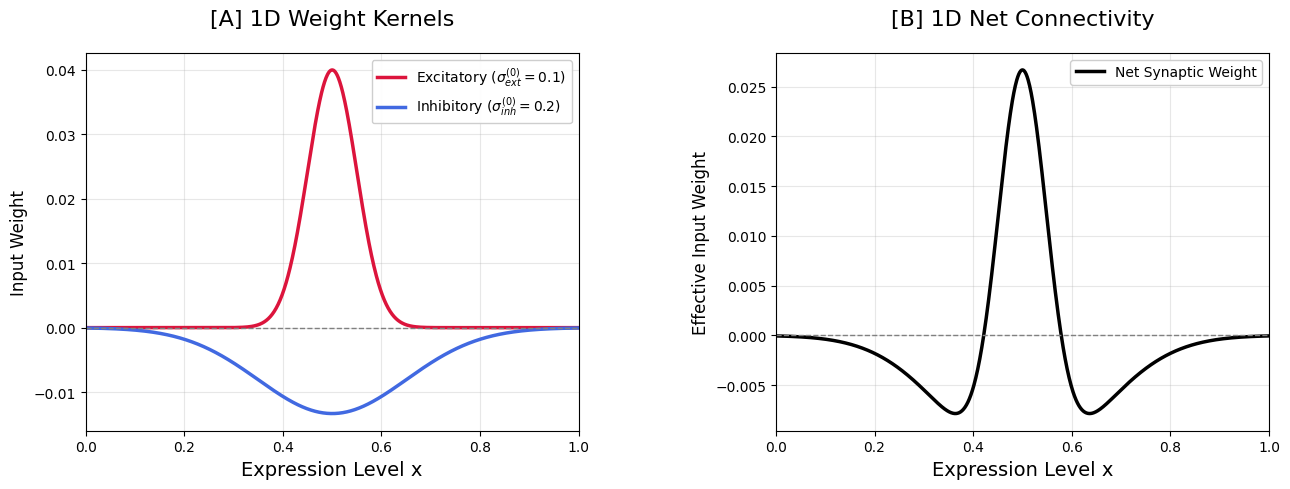

In [ ]:
x0 = 0.5
sig_E, sig_I = 0.05, 0.15

c = 0.002
A_E = c / sig_E
A_I = c / sig_I

x = np.linspace(0, 1, 1000)

w_E = A_E * np.exp(-0.5 * (x - x0) ** 2 / sig_E ** 2)
w_I = -A_I * np.exp(-0.5 * (x - x0) ** 2 / sig_I ** 2)
w = w_E + w_I

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(x, w_E, color='crimson', lw=2.5,
        label=r'Excitatory ($\sigma^{(0)}_{ext} = 0.1$)')
ax.plot(x, w_I, color='royalblue', lw=2.5,
        label=r'Inhibitory ($\sigma^{(0)}_{inh} = 0.2$)')
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_title('[A] 1D Weight Kernels', fontsize=16, pad=20)
ax.set_ylabel('Input Weight', fontsize=12)
ax.legend(loc='upper right', framealpha=0.95)

ax = axes[1]
ax.plot(x, w, color='black', lw=2.5, label='Net Synaptic Weight')
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_title('[B] 1D Net Connectivity', fontsize=16, pad=20)
ax.set_ylabel('Effective Input Weight', fontsize=12)
ax.legend(loc='upper right', framealpha=0.95)

for ax in axes:
    ax.set_xlabel('Expression Level x', fontsize=14)
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.3)


fig.tight_layout()
fig.subplots_adjust(wspace=0.4) 
plt.show()

9. Plot Elongated Gaussian Connectivity

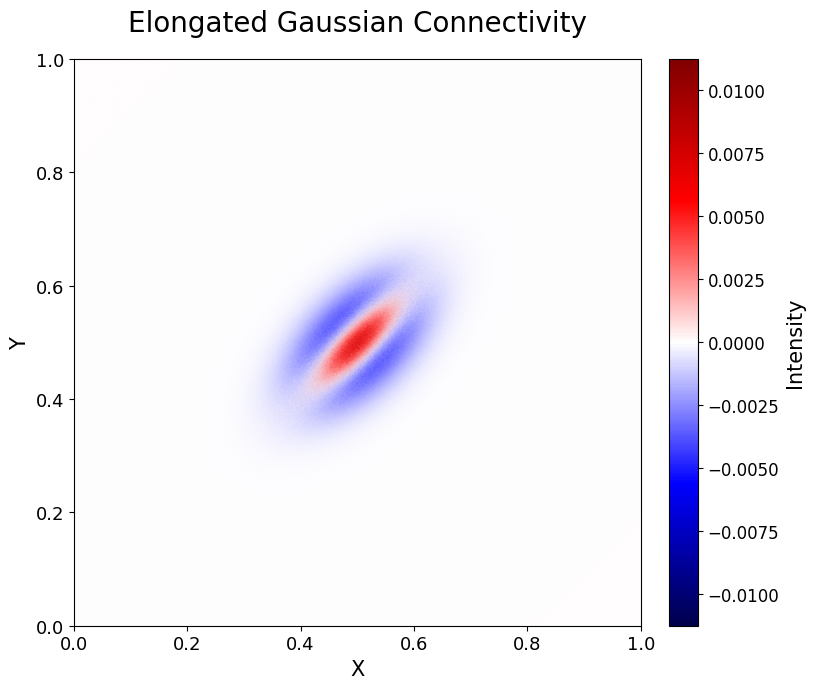

In [41]:
rng = np.random.default_rng(187)
n_grid = 5000
x0, y0 = 0.5, 0.5
theta = 0.25 * np.pi
sig_x_E, sig_y_E = 0.045*1.5, 0.016*1.5
sig_x_I, sig_y_I = 0.058*1.5, 0.032*1.5
a_E, a_I = 1.0, 0.58
peak = 0.015
noise = 0.06

g = np.linspace(0, 1, n_grid, dtype=np.float32)
X, Y = np.meshgrid(g, g, indexing='xy')
dx, dy = X - x0, Y - y0
u = dx * np.cos(theta) + dy * np.sin(theta)
v = -dx * np.sin(theta) + dy * np.cos(theta)
del X, Y, dx, dy

K_E = a_E * np.exp(-0.5 * (u**2 / sig_x_E**2 + v**2 / sig_y_E**2))
K_I = a_I * np.exp(-0.5 * (u**2 / sig_x_I**2 + v**2 / sig_y_I**2))
del u, v

env = np.sqrt(np.maximum(K_E, 0)) + np.sqrt(np.maximum(K_I, 0))
K_E += noise * env * rng.standard_normal(K_E.shape, dtype=np.float32)
K_I += noise * env * rng.standard_normal(K_I.shape, dtype=np.float32)
del env

K = K_E - K_I
del K_E, K_I
K *= peak / np.abs(K).max()

fig, ax = plt.subplots(figsize=(8.5, 7))

lim = np.abs(K * 0.75).max()
im = ax.imshow(K, origin='lower', extent=[0, 1, 0, 1],
               cmap='seismic', vmin=-lim, vmax=lim)
ax.set_title('Elongated Gaussian Connectivity', fontsize=20, pad=20)
ax.set_xlabel('X', fontsize=15)
ax.set_ylabel('Y', fontsize=15)
ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.tick_params(labelsize=13)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label('Intensity', fontsize=15)
cb.ax.tick_params(labelsize=12)

fig.tight_layout()

10. Plot Gaussian Prob Scaling

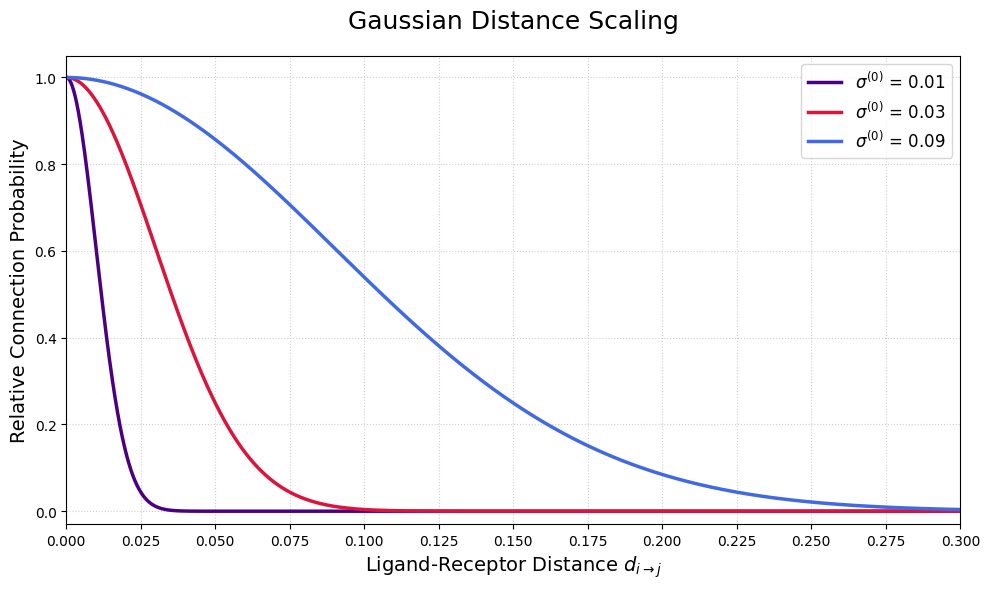

In [47]:
import numpy as np
import matplotlib.pyplot as plt

sigmas = [0.01, 0.03, 0.09]
colors = ['indigo', 'crimson', 'royalblue']

d = np.linspace(0, 0.3, 1801)

plt.figure(figsize=(10, 6))
for sigma, color in zip(sigmas, colors):
    p = np.exp(-d**2 / (2 * sigma**2))
    plt.plot(d, p, linestyle='-', color=color, linewidth=2.5,
             label=rf'$\sigma^{{(0)}}$ = {sigma}')

plt.title('Gaussian Distance Scaling', fontsize=18, pad=20)
plt.xlabel(r'Ligand-Receptor Distance $d_{i\rightarrow j}$', fontsize=14)
plt.ylabel('Relative Connection Probability', fontsize=14)
plt.xticks(np.arange(0, 0.31, 0.025))
plt.xlim(0, 0.3)
plt.ylim(-0.03, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()